In [1]:
%matplotlib inline

from collections.abc import Callable

import torch
from torch import nn
from torch.optim import lr_scheduler
from d2l import torch as d2l

In [2]:
# Modernized LeNet

def create_lenet() -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(
            in_channels=1,
            out_channels=6,
            kernel_size=5,
            padding=2,
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        ),
        nn.Conv2d(
            in_channels=6,
            out_channels=16,
            kernel_size=5,
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        ),
        nn.Flatten(),
        nn.Linear(
            in_features=16 * 5 * 5,
            out_features=120,
        ),
        nn.ReLU(),
        nn.Linear(
            in_features=120,
            out_features=84,
        ),
        nn.ReLU(),
        nn.Linear(
            in_features=84,
            out_features=10,
        ),
    )


model = create_lenet()

sample_input = torch.randn(
    1,
    1,
    28,
    28,
)

with torch.no_grad():
    sample_output = model(
        sample_input
    )

print(
    "Input shape:",
    tuple(sample_input.shape),
)
print(
    "Output shape:",
    tuple(sample_output.shape),
)

Input shape: (1, 1, 28, 28)
Output shape: (1, 10)


In [3]:
# Fashion-MNIST와 Device 설정

batch_size = 256

train_iterator, test_iterator = (
    d2l.load_data_fashion_mnist(
        batch_size=batch_size,
    )
)

loss_function = nn.CrossEntropyLoss()
device = d2l.try_gpu()

print("Device:", device)

Device: cuda:0


In [4]:
# Scheduler를 지원하는 Training Function

LossFunction = Callable[
    [torch.Tensor, torch.Tensor],
    torch.Tensor,
]

CustomScheduler = Callable[
    [int],
    float,
]

Scheduler = (
    lr_scheduler.LRScheduler
    | CustomScheduler
)


def train(
    model: nn.Module,
    train_iterator: torch.utils.data.DataLoader,
    test_iterator: torch.utils.data.DataLoader,
    num_epochs: int,
    loss_function: LossFunction,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scheduler: Scheduler | None = None,
) -> None:
    model.to(device)

    animator = d2l.Animator(
        xlabel="epoch",
        xlim=[0, num_epochs],
        legend=[
            "train loss",
            "train acc",
            "test acc",
        ],
    )

    for epoch in range(num_epochs):
        metric = d2l.Accumulator(3)

        for batch_index, (
            features,
            labels,
        ) in enumerate(train_iterator):
            model.train()
            optimizer.zero_grad()

            features = features.to(device)
            labels = labels.to(device)

            predictions = model(features)

            loss_value = loss_function(
                predictions,
                labels,
            )

            loss_value.backward()
            optimizer.step()

            with torch.no_grad():
                metric.add(
                    loss_value.detach()
                    * features.shape[0],
                    d2l.accuracy(
                        predictions,
                        labels,
                    ),
                    features.shape[0],
                )

            train_loss = (
                metric[0] / metric[2]
            )

            train_accuracy = (
                metric[1] / metric[2]
            )

            if (
                batch_index + 1
            ) % 50 == 0:
                animator.add(
                    epoch
                    + batch_index
                    / len(train_iterator),
                    (
                        train_loss,
                        train_accuracy,
                        None,
                    ),
                )

        test_accuracy = (
            d2l.evaluate_accuracy_gpu(
                model,
                test_iterator,
            )
        )

        animator.add(
            epoch + 1,
            (
                None,
                None,
                test_accuracy,
            ),
        )

        if scheduler is not None:
            if isinstance(
                scheduler,
                lr_scheduler.LRScheduler,
            ):
                scheduler.step()

            else:
                scheduled_learning_rate = (
                    scheduler(epoch)
                )

                for parameter_group in (
                    optimizer.param_groups
                ):
                    parameter_group[
                        "lr"
                    ] = scheduled_learning_rate

    print(
        f"train loss {train_loss:.3f}, "
        f"train acc {train_accuracy:.3f}, "
        f"test acc {test_accuracy:.3f}"
    )

Epoch 0: 0.5
Epoch 15: 0.25
Epoch 30: 0.125


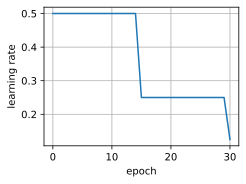

In [5]:
# Multi-Step Schedule 시각화

def record_learning_rate(
    optimizer: torch.optim.Optimizer,
    scheduler: lr_scheduler.LRScheduler,
) -> float:
    current_learning_rate = (
        scheduler.get_last_lr()[0]
    )

    optimizer.step()
    scheduler.step()

    return current_learning_rate


preview_model = create_lenet()

preview_optimizer = torch.optim.SGD(
    preview_model.parameters(),
    lr=0.5,
)

preview_scheduler = (
    lr_scheduler.MultiStepLR(
        preview_optimizer,
        milestones=[
            15,
            30,
        ],
        gamma=0.5,
    )
)

preview_updates = 31

learning_rates = [
    record_learning_rate(
        preview_optimizer,
        preview_scheduler,
    )
    for _ in range(preview_updates)
]

d2l.plot(
    torch.arange(preview_updates),
    learning_rates,
    xlabel="epoch",
    ylabel="learning rate",
)

print(
    "Epoch 0:",
    learning_rates[0],
)
print(
    "Epoch 15:",
    learning_rates[15],
)
print(
    "Epoch 30:",
    learning_rates[30],
)

train loss 0.156, train acc 0.940, test acc 0.886


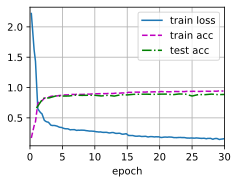

In [6]:
# Multi-Step Scheduler로 학습

learning_rate = 0.5
num_epochs = 30

model = create_lenet()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate,
)

scheduler = lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[
        15,
        30,
    ],
    gamma=0.5,
)

train(
    model,
    train_iterator,
    test_iterator,
    num_epochs,
    loss_function,
    optimizer,
    device,
    scheduler,
)